# CNN Surrogate Model for Groundwater Head Prediction

This notebook trains and evaluates a Convolutional Neural Network (CNN) surrogate model that learns the temporal evolution of hydraulic head fields from MODFLOW simulations. It provides physics-informed evaluation including PDE residuals, mass balance errors, and Dirichlet boundary condition consistency.

Physics-based evaluation covers:
- Autoregressive rollout metrics (MAE, RMSE, RRMSE, R²)
- Nonlinear Boussinesq PDE residuals
- Finite-volume mass balance error
- Dirichlet boundary condition consistency

**Sections:**
1. Setup & Configuration
2. Data Utilities & Dataset
3. Model Architecture & Training
4. Model Inspection
5. Metric Evaluation
6. Rollout Metrics
7. Visualization – Spatial Error Maps
8. Physics-Based Evaluation (PDE Residuals)
9. Boundary Condition Analysis

## 1. Setup & Configuration

In [ ]:
#!/usr/bin/env python
import torch, re, os, glob
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
import json
import pandas as pd
import numpy as np
import random, shutil
from scipy.interpolate import griddata

# ── Data path configuration ──────────────────────────────────────────────
# Set DATA_DIR to the folder containing your MODFLOW .txt output files.
# Expected file naming convention: t{timestep}.txt  (e.g., t1.txt, t2.txt, ...)
DATA_DIR = './data'  # <-- Change this to your data directory
DATA_PATTERN = os.path.join(DATA_DIR, 't*.txt')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Mounted at /content/drive/


## 2. Data Utilities & Dataset

In [ ]:
# =========================
# Utils
# =========================
def set_seed(seed=42):
    """
    Set random seeds for reproducibility
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_txt_to_grid(path):
    """
    Load MODFLOW txt file (x y h) → structured 2D grid
    """
    data = np.loadtxt(path)
    x, y, h = data[:, 0], data[:, 1], data[:, -1]

    x_unique = np.unique(x)
    y_unique = np.unique(y)

    nx, ny = len(x_unique), len(y_unique)

    xi = np.searchsorted(x_unique, x)
    yi = np.searchsorted(y_unique, y)

    H = np.full((ny, nx), np.nan)
    H[yi, xi] = h

    # Fill NaNs with nearest neighbor interpolation
    if np.any(np.isnan(H)):
        from scipy.interpolate import griddata
        mask = ~np.isnan(H)
        yy, xx = np.mgrid[0:ny, 0:nx]
        H = griddata((yy[mask], xx[mask]), H[mask], (yy, xx), method='nearest')

    return H, x_unique, y_unique


# =========================
# Dataset
# =========================
class GroundwaterDataset(Dataset):
    """
    (H_t-1) → (H_t) with temporal splits
    """
    def __init__(self, txt_files, start_idx=0, end_idx=None, mean=None, std=None):
        self.txt_files = txt_files

        if end_idx is None:
            end_idx = len(self.txt_files)

        self.txt_files = self.txt_files[start_idx:end_idx]

        self.grids = []
        for f in self.txt_files:
            H, _, _ = load_txt_to_grid(f)
            self.grids.append(H)

        self.grids = np.array(self.grids)

        # Normalize (use provided stats or compute from data)
        if mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            self.mean = np.mean(self.grids)
            self.std = np.std(self.grids)

        self.grids = (self.grids - self.mean) / (self.std + 1e-8)

    def __len__(self):
        return len(self.grids) - 1

    def __getitem__(self, idx):
        x = self.grids[idx]
        y = self.grids[idx + 1]

        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(0)

        return x, y


## 3. Model Architecture & Training

In [ ]:


# ─── Configuration ────────────────────────────────────────────────────────────
# Edit these values before running.
DATA_PATH  = "./data/t*.txt"   # Glob pattern for MODFLOW head files
EPOCHS     = 100
LR         = 1e-3
BATCH_SIZE = 4
SEED       = 42


# ─── Model, metrics & helpers ─────────────────────────────────────────────────

class HeadCNN(nn.Module):
    """
    Lightweight fully-convolutional network: H_t → H_{t+1}.
    Three 3×3 Conv2d layers with GELU activations and same-padding.
    """
    def __init__(self, in_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 32, 3, padding=1),          nn.GELU(),
            nn.Conv2d(32, 1,  3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


def mae(pred, true):
    return torch.mean(torch.abs(pred - true)).item()

def rmse(pred, true):
    return torch.sqrt(torch.mean((pred - true) ** 2)).item()


def multi_step_predict(model, initial_state, n_steps, device):
    """Autoregressively predict n_steps ahead from initial_state."""
    model.eval()
    predictions, current = [], initial_state.to(device)
    with torch.no_grad():
        for _ in range(n_steps):
            pred = model(current)
            predictions.append(pred.cpu())
            current = pred
    return predictions


def evaluate_multistep(model, dataset, device, steps=(1, 5, 10)):
    """
    Evaluate RMSE for multi-step rollouts.
    Automatically skips horizons that exceed the available test samples.
    """
    model.eval()
    results = {}
    max_possible = len(dataset) - 1

    for n_steps in steps:
        if n_steps > max_possible:
            print(f"{n_steps}-step rollout skipped "
                  f"(only {max_possible} test samples available)")
            continue

        errors = []
        for i in range(min(10, len(dataset) - n_steps + 1)):
            x, _ = dataset[i]
            x = x.unsqueeze(0).to(device)
            true_states = [dataset[j][1] for j in range(i, min(i + n_steps, len(dataset)))]
            preds = multi_step_predict(model, x, len(true_states), device)
            for pred, true in zip(preds, true_states):
                errors.append(rmse(pred.to(device), true.unsqueeze(0).to(device)))

        results[f'{n_steps}_step'] = {
            'mean_rmse': float(np.mean(errors)),
            'std_rmse':  float(np.std(errors)),
        }
        print(f"{n_steps}-step RMSE: {np.mean(errors):.4f} \u00b1 {np.std(errors):.4f}")

    return results


def run_multiple_seeds(n_runs=5, epochs=EPOCHS, lr=LR,
                       batch_size=BATCH_SIZE, data_path=DATA_PATH):
    """Train with multiple seeds and aggregate results for statistical robustness."""
    all_results = []
    for run in range(n_runs):
        seed = 42 + run
        print(f"\n{'='*60}\nRUN {run+1}/{n_runs}  seed={seed}\n{'='*60}")
        _, _, _, _, results = train(seed=seed, epochs=epochs, lr=lr,
                                    batch_size=batch_size, data_path=data_path)
        all_results.append(results)

    metrics    = ['test_mse', 'test_mae', 'test_rmse']
    aggregated = {
        m: {k: float(f([r[m] for r in all_results]))
            for k, f in [('mean', np.mean), ('std', np.std),
                         ('min', np.min),  ('max', np.max)]}
        for m in metrics
    }
    print(f"\n{'='*60}\nAGGREGATED RESULTS ({n_runs} runs)\n{'='*60}")
    for m in metrics:
        s = aggregated[m]
        print(f"{m.upper():12s}: {s['mean']:.4f} \u00b1 {s['std']:.4f} "
              f"(min={s['min']:.4f}, max={s['max']:.4f})")
    with open("outputs/aggregated_results.json", 'w') as f:
        json.dump(aggregated, f, indent=2)
    return all_results, aggregated


# ─── Training ─────────────────────────────────────────────────────────────────

def train(seed=SEED, epochs=EPOCHS, lr=LR,
          batch_size=BATCH_SIZE, data_path=DATA_PATH):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    txt_files = sorted(glob.glob(data_path), key=extract_time)
    if not txt_files:
        raise ValueError(f"No files found at {data_path}")

    n_total = len(txt_files)
    n_train = int(0.6 * n_total)
    n_val   = int(0.2 * n_total)
    n_test  = n_total - n_train - n_val
    print(f"Found {n_total} timesteps  |  Train={n_train}, Val={n_val}, Test={n_test}")

    train_ds = GroundwaterDataset(txt_files, 0, n_train)
    val_ds   = GroundwaterDataset(txt_files, n_train, n_train + n_val,
                                  mean=train_ds.mean, std=train_ds.std)
    test_ds  = GroundwaterDataset(txt_files, n_train + n_val, n_total,
                                  mean=train_ds.mean, std=train_ds.std)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

    model     = HeadCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10)
    criterion = nn.MSELoss()

    os.makedirs("outputs", exist_ok=True)
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_rmse': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_loss = val_mae_sum = val_rmse_sum = 0.0
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_loss     += criterion(pred, yb).item()
                val_mae_sum  += mae(pred, yb)
                val_rmse_sum += rmse(pred, yb)

        avg_train = train_loss   / len(train_loader)
        avg_val   = val_loss     / len(val_loader)
        avg_mae   = val_mae_sum  / len(val_loader)
        avg_rmse  = val_rmse_sum / len(val_loader)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_mae'].append(avg_mae)
        history['val_rmse'].append(avg_rmse)

        scheduler.step(avg_val)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train MSE: {avg_train:.4e} | "
                  f"Val MSE: {avg_val:.4e} | MAE: {avg_mae:.3f} | RMSE: {avg_rmse:.3f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'mean': train_ds.mean,
                'std':  train_ds.std,
            }, "outputs/cnn_best_model.pth")

    checkpoint = torch.load("outputs/cnn_best_model.pth", weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\nLoaded best model from epoch {checkpoint['epoch']}")

    # ── Test evaluation ──────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        test_loss = test_mae_sum = test_rmse_sum = 0.0
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            test_loss     += criterion(pred, yb).item()
            test_mae_sum  += mae(pred, yb)
            test_rmse_sum += rmse(pred, yb)

    test_results = {
        'test_mse':  test_loss     / len(test_loader),
        'test_mae':  test_mae_sum  / len(test_loader),
        'test_rmse': test_rmse_sum / len(test_loader),
        'seed': seed,
    }
    print("\n" + "="*50)
    print("TEST SET RESULTS")
    print("="*50)
    print(f"Test MSE:  {test_results['test_mse']:.4e}")
    print(f"Test MAE:  {test_results['test_mae']:.4f} m")
    print(f"Test RMSE: {test_results['test_rmse']:.4f} m")
    print("="*50)

    # ── Save predictions as MODFLOW-style .txt ───────────────────────────────
    save_dir = "outputs/test_predictions"
    os.makedirs(save_dir, exist_ok=True)
    with torch.no_grad():
        for i in range(len(test_ds)):
            x, _ = test_ds[i]
            pred_norm = model(x.unsqueeze(0).to(device)).squeeze().cpu().numpy()
            pred      = pred_norm * test_ds.std + test_ds.mean
            target_file = test_ds.txt_files[i + 1]
            data   = np.loadtxt(target_file)
            coords = data[:, :2]
            assert coords.shape[0] == pred.size, "Grid size mismatch"
            basename = os.path.basename(target_file)
            np.savetxt(
                os.path.join(save_dir, f"cnn_pred_{basename}"),
                np.column_stack([coords[:, 0], coords[:, 1], pred.reshape(-1)]),
                fmt="%.6f", header="x y h", comments=""
            )
            print(f"  Saved: cnn_pred_{basename}")
    print("All test predictions saved.")

    with open(f"outputs/results_seed_{seed}.json", 'w') as f:
        json.dump(test_results, f, indent=2)
    with open(f"outputs/history_seed_{seed}.json", 'w') as f:
        json.dump(history, f, indent=2)

    print("Training finished.")
    return model, train_ds, val_ds, test_ds, test_results


# ─── Run ──────────────────────────────────────────────────────────────────────
# For multiple statistical runs use: run_multiple_seeds()
model, train_ds, val_ds, test_ds, results = train()


Running single training...
Using device: cuda
Ordered timesteps:
0.25 t0.25.txt
0.5 t0.5.txt
0.75 t0.75.txt
1.0 t1.txt
2.0 t2.txt
3.0 t3.txt
4.0 t4.txt
5.0 t5.txt
6.0 t6.txt
7.0 t7.txt
8.0 t8.txt
9.0 t9.txt
10.0 t10.txt
11.0 t11.txt
12.0 t12.txt
13.0 t13.txt
14.0 t14.txt
15.0 t15.txt
16.0 t16.txt
17.0 t17.txt
18.0 t18.txt
19.0 t19.txt
20.0 t20.txt
21.0 t21.txt
22.0 t22.txt
23.0 t23.txt
24.0 t24.txt
25.0 t25.txt
26.0 t26.txt
27.0 t27.txt
28.0 t28.txt
29.0 t29.txt
30.0 t30.txt
Found 33 time steps
Split: Train=19, Val=6, Test=8

TRAINING files (indices 0 to 18):
  0: t0.25.txt (t=0.25)
  1: t0.5.txt (t=0.5)
  2: t0.75.txt (t=0.75)
  3: t1.txt (t=1.0)
  4: t2.txt (t=2.0)
  ... and 14 more

VALIDATION files (indices 19 to 24):
  19: t17.txt (t=17.0)
  20: t18.txt (t=18.0)
  21: t19.txt (t=19.0)
  22: t20.txt (t=20.0)
  23: t21.txt (t=21.0)
  ... and 1 more

TEST files (indices 25 to 32):
  25: t23.txt (t=23.0)
  26: t24.txt (t=24.0)
  27: t25.txt (t=25.0)
  28: t26.txt (t=26.0)
  29: t27.tx

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Training finished.

Available test set files (total: 8):
  Index 0: t=23.0 (t23.txt)
  Index 1: t=24.0 (t24.txt)
  Index 2: t=25.0 (t25.txt)
  Index 3: t=26.0 (t26.txt)
  Index 4: t=27.0 (t27.txt)
  Index 5: t=28.0 (t28.txt)
  Index 6: t=29.0 (t29.txt)
  Index 7: t=30.0 (t30.txt)

Visualizing test indices [0, 1, 2, 3] -> timesteps: [23.0, 24.0, 25.0, 26.0]



## 4. Model Inspection

In [ ]:
# Print model architecture
print("Model Architecture:")
print(model)

# Calculate and print parameter counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Print detailed parameter shapes
print("\nParameter Shapes:")
for name, param in model.named_parameters():
    print(f"  {name}: {list(param.shape)}")

Model Architecture:
HeadCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

Total parameters: 9,857
Trainable parameters: 9,857

Parameter Shapes:
  net.0.weight: [32, 1, 3, 3]
  net.0.bias: [32]
  net.2.weight: [32, 32, 3, 3]
  net.2.bias: [32]
  net.4.weight: [1, 32, 3, 3]
  net.4.bias: [1]


> **Note:** The cell below is a condensed version of the parameter summary above.

## 5. Metric Evaluation


### Simplified Test Evaluation

> Evaluation loop that computes MSE, RMSE, MAE, and R² on the full test set without horizon decomposition.

In [ ]:
# Test the model on test set

# Redefine test_loader and criterion as they were not globally available from train()
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
criterion = nn.MSELoss()

model.eval()
test_loss = 0.0
test_mae = 0.0
all_predictions = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)

        test_loss += criterion(pred, yb).item()
        test_mae += torch.mean(torch.abs(pred - yb)).item()

        # Store for R² calculation
        all_predictions.append(pred.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

# Concatenate all predictions and targets
all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Calculate metrics
avg_test_loss = test_loss / len(test_loader)
avg_test_mae = test_mae / len(test_loader)

test_rmse = np.sqrt(avg_test_loss) * train_ds.std
test_mae_physical = avg_test_mae * train_ds.std

# Calculate R²
ss_res = np.sum((all_targets - all_predictions) ** 2)
ss_tot = np.sum((all_targets - np.mean(all_targets)) ** 2)
r2_score = 1 - (ss_res / ss_tot)

print("\n=== Test Set Performance ===")
print(f"MSE:  {avg_test_loss:.6f}")
print(f"RMSE: {test_rmse:.3f} m")
print(f"MAE:  {test_mae_physical:.3f} m")
print(f"R²:   {r2_score:.6f}")


=== Test Set Performance ===
MSE:  0.005017
RMSE: 0.079 m
MAE:  0.066 m
R²:   0.995380


## 6. Autoregressive Rollout Metrics

### Full Rollout Metrics (MAE / RMSE / RRMSE / R²)

> **This is the canonical evaluation cell.** Computes all four metrics across autoregressive rollout horizons h = 1–5

In [ ]:
def denorm(x_norm, mean, std):
    # x_norm: torch tensor
    return x_norm * std + mean

@torch.no_grad()
def rollout_metrics_and_report(model, test_ds, device, seq_len, horizons, mean, std):
    """
    Computes MAE, RMSE, RRMSE, and R² for autoregressive rollouts
    and reports them in the exact format of the PINN output.
    """
    # Ensure sorted horizons and unique
    horizons = sorted(set(horizons))

    # Storage for all predictions/targets per horizon to calculate global metrics later
    horizon_data = {h: {'preds': [], 'targets': []} for h in horizons}

    N_test_grids = len(test_ds.grids) # Total number of individual grids

    # --- 1. RUN ROLLOUTS & COLLECT DATA ---
    for h in horizons:

        max_start_idx_for_h = N_test_grids - seq_len - h

        if max_start_idx_for_h < 0:

            continue

        for start_idx in range(max_start_idx_for_h + 1):
            xb, _ = test_ds[start_idx]

            # Prepare Input
            xb_t = xb
            if isinstance(xb_t, np.ndarray): xb_t = torch.from_numpy(xb_t)
            if xb_t.ndim == 3: xb_t = xb_t.unsqueeze(0)
            elif xb_t.ndim == 4 and xb_t.shape[0] != 1: xb_t = xb_t[:1]
            xb_t = xb_t.to(device)

            # Rollout Loop
            roll_in = xb_t.clone()

            for step in range(1, h + 1):
                pred_norm = model(roll_in)


                if step == h:

                    true_grid_idx = start_idx + seq_len + (h - 1)
                    y_norm = torch.tensor(test_ds.grids[true_grid_idx], dtype=torch.float32).to(device)
                    y_norm = y_norm.unsqueeze(0).unsqueeze(0)

                    # Denorm to Physical Units (Meters)
                    pred_phys = denorm(pred_norm, mean, std).cpu().numpy()
                    y_phys    = denorm(y_norm, mean, std).cpu().numpy()

                    horizon_data[h]['preds'].append(pred_phys)
                    horizon_data[h]['targets'].append(y_phys)

                # Update window for next step
                if step < h:
                    roll_in = torch.cat([roll_in[:, 1:], pred_norm[:, 0].unsqueeze(1)], dim=1)

    # --- 2. CALCULATE METRICS PER HORIZON ---
    print("\n=== Testing on Rollout Horizons (Extrapolation) ===")

    # Lists to store metrics across horizons (for the Final Summary)
    summary_mae = []
    summary_rrmse = []
    summary_r2 = []
    summary_rmse = []

    for h in horizons:
        preds = horizon_data[h]['preds']
        targets = horizon_data[h]['targets']

        if len(preds) == 0:
            print(f"  h={h}: No data processed")
            continue

        # Convert list of arrays to single numpy array
        preds = np.concatenate(preds, axis=0)
        targets = np.concatenate(targets, axis=0)

        # A. MAE
        h_mae = np.mean(np.abs(preds - targets))

        # B. RMSE & RRMSE
        h_mse = np.mean((preds - targets)**2)
        h_rmse = np.sqrt(h_mse)
        target_mean = np.mean(targets)
        h_rrmse = (h_rmse / target_mean) * 100 if target_mean != 0 else 0.0

        # C. R²
        ss_res = np.sum((targets - preds)**2)
        ss_tot = np.sum((targets - target_mean)**2)
        h_r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

        summary_mae.append(h_mae)
        summary_rrmse.append(h_rrmse)
        summary_r2.append(h_r2)
        summary_rmse.append(h_rmse) # Store RMSE

        print(f"  h={h:<2}: MAE={h_mae:.3f}m, RMSE={h_rmse:.3f}m, RRMSE={h_rrmse:.3f}%, R²={h_r2:.6f}")

    # --- FINAL SUMMARY (AVERAGE ACROSS HORIZONS) ---
    if len(summary_mae) > 0:
        avg_mae = np.mean(summary_mae)
        avg_rrmse = np.mean(summary_rrmse)
        avg_r2 = np.mean(summary_r2)
        avg_rmse = np.mean(summary_rmse) # Calculate average RMSE

        std_mae = np.std(summary_mae)
        std_rrmse = np.std(summary_rrmse)
        std_r2 = np.std(summary_r2)
        std_rmse = np.std(summary_rmse) # Calculate std of RMSE

        print("\n--- FINAL TEST RESULTS (h=1-5) ---")
        print(f"Average MAE:    {avg_mae:.3f} m")
        print(f"Average RMSE:   {avg_rmse:.3f} m")
        print(f"Average RRMSE:  {avg_rrmse:.3f} %")
        print(f"Average R²:     {avg_r2:.6f}")
        print(f"Std MAE:        {std_mae:.3f} m")
        print(f"Std RMSE:       {std_rmse:.3f} m")
        print(f"Std RRMSE:      {std_rrmse:.3f} %")
        print(f"Std R²:         {std_r2:.6f}")
        print("------------------------------------")
    else:
        print("No valid data found for horizons.")

# -------------------------
# RUN CONFIGURATION
# -------------------------
# Define the sequence length for this specific rollout analysis
SEQ_LEN_ROLLOUT = 1
valid_horizons = [1, 2, 3, 4, 5]


new_test_ds = GroundwaterDataset(
    txt_files=test_ds.txt_files,
    start_idx=0,
    end_idx=None,
    mean=train_ds.mean,
    std=train_ds.std,

)

# Convert train stats to float tensors for the function
mean_t = torch.tensor(float(train_ds.mean), device=device, dtype=torch.float32)
std_t  = torch.tensor(float(train_ds.std), device=device, dtype=torch.float32)

rollout_metrics_and_report(
    model=model,
    test_ds=new_test_ds,
    device=device,
    seq_len=SEQ_LEN_ROLLOUT,
    horizons=valid_horizons,
    mean=mean_t,
    std=std_t
)


=== Testing on Rollout Horizons (Extrapolation) ===
  h=1 : MAE=0.066m, RMSE=0.079m, RRMSE=0.089%, R²=0.995380
  h=2 : MAE=0.129m, RMSE=0.147m, RRMSE=0.166%, R²=0.983989
  h=3 : MAE=0.191m, RMSE=0.212m, RRMSE=0.240%, R²=0.966712
  h=4 : MAE=0.251m, RMSE=0.276m, RRMSE=0.312%, R²=0.943742
  h=5 : MAE=0.311m, RMSE=0.338m, RRMSE=0.383%, R²=0.915286

--- FINAL TEST RESULTS (h=1-5) ---
Average MAE:    0.190 m
Average RMSE:   0.210 m
Average RRMSE:  0.238 %
Average R²:     0.961022
Std MAE:        0.087 m
Std RMSE:       0.092 m
Std RRMSE:      0.104 %
Std R²:         0.028743
------------------------------------


## 7. Visualization – Spatial Error Maps

The cells below produce spatial absolute error maps for the CNN.
> Uses a clipped color scale to reveal low-level spatial error patterns that would otherwise be washed out by pumping-well singularities.
> Error maps computed from autoregressive (free-run) rollout predictions, revealing compounding error accumulation across stress periods.

FIGURE 3b: ROBUST ERROR MAPS (ConvLSTM) - Rollout Predictions
Rolling out 5 steps from initial input...
  h=1 (t=26.0 d) | MAE=0.065 m | Max=0.798 m
  h=2 (t=27.0 d) | MAE=0.129 m | Max=1.005 m
  h=3 (t=28.0 d) | MAE=0.190 m | Max=1.086 m
  h=4 (t=29.0 d) | MAE=0.251 m | Max=1.127 m
  h=5 (t=30.0 d) | MAE=0.311 m | Max=1.152 m

True Maximum Error:   1.1520 m
99th Percentile Cap:  0.5867 m


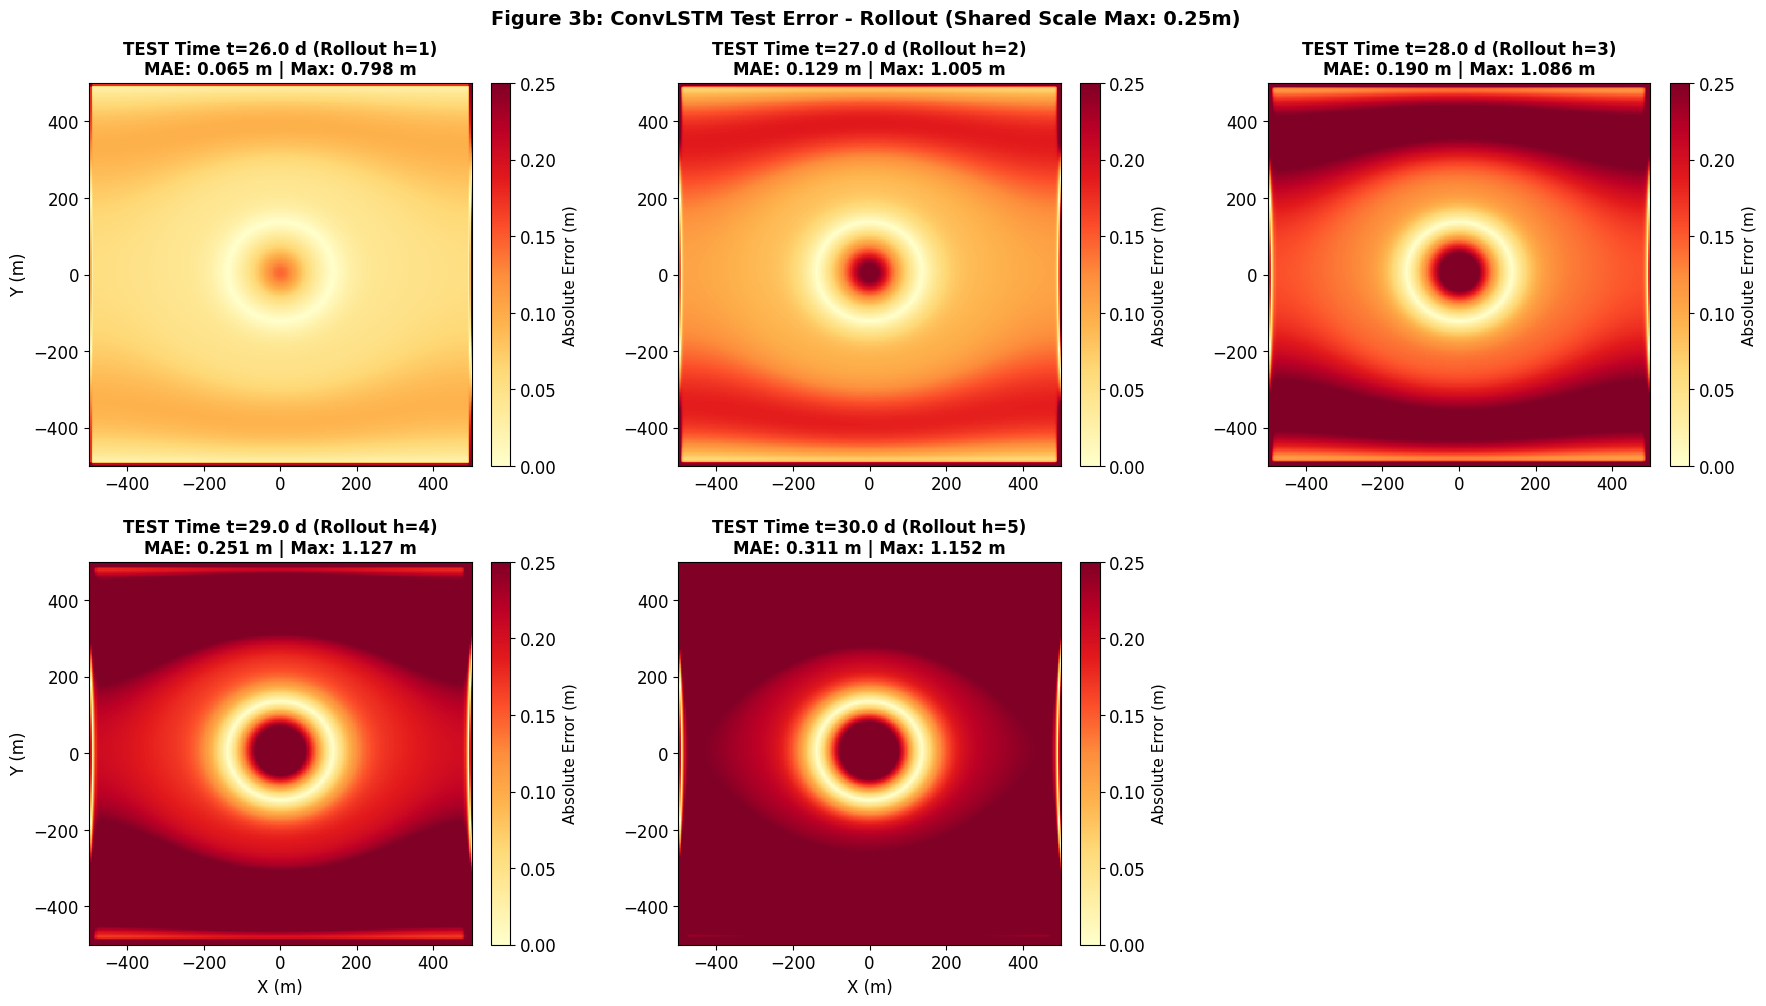

In [ ]:

# ==========================================
#  ROLLOUT ERROR MAP CNN
# ==========================================
model.eval()

print("=" * 80)
print("ROBUST ERROR MAPS (CNN) - Rollout Predictions")
print("=" * 80)

# 1. Physical Domain
x_min, x_max = -500, 500
y_min, y_max = -500, 500

# 2. Rollout from last training frame
num_horizons = 5
target_times = [26.0, 27.0, 28.0, 29.0, 30.0]


xb_start, _ = test_ds[0]
if isinstance(xb_start, np.ndarray):
    xb_start = torch.from_numpy(xb_start)
if xb_start.ndim == 3:
    xb_start = xb_start.unsqueeze(0)
roll_in = xb_start.to(device)

# 3. Rollout and collect error maps
all_errors_flat = []
plot_data = []

print(f"Rolling out {num_horizons} steps from initial input...")

with torch.no_grad():
    for h in range(num_horizons):
        # Predict next step
        pred_norm = model(roll_in)

        # Get ground truth for this horizon
        # test_ds[h] gives (input_h, target_h)
        _, yb = test_ds[h]
        if isinstance(yb, np.ndarray):
            yb = torch.from_numpy(yb)
        yb = yb.unsqueeze(0).to(device)

        # Denormalize to physical units
        pred_phys = pred_norm[0, 0].cpu().numpy() * train_ds.std + train_ds.mean
        true_phys = yb[0, 0].cpu().numpy() * train_ds.std + train_ds.mean

        abs_err = np.abs(pred_phys - true_phys)
        all_errors_flat.append(abs_err.flatten())

        t_val = target_times[h]
        mae = np.mean(abs_err)
        local_max = np.max(abs_err)
        print(f"  h={h+1} (t={t_val:.1f} d) | MAE={mae:.3f} m | Max={local_max:.3f} m")

        plot_data.append((t_val, abs_err))


        roll_in = torch.cat([roll_in[:, 1:], pred_norm[:, 0].unsqueeze(1)], dim=1)

all_errors_flat = np.concatenate(all_errors_flat)

# 4. Robust Scale
vmax_robust = np.percentile(all_errors_flat, 99)
max_real = np.max(all_errors_flat)

print(f"\nTrue Maximum Error:   {max_real:.4f} m")
print(f"99th Percentile Cap:  {vmax_robust:.4f} m")

# 5. Plot
fig = plt.figure(figsize=(18, 10))

for plot_idx, (t_val, abs_error) in enumerate(plot_data):
    ax = fig.add_subplot(2, 3, plot_idx + 1)

    im = ax.imshow(abs_error, cmap='YlOrRd', interpolation='nearest',
                   extent=[x_min, x_max, y_min, y_max], origin='lower',
                   vmin=0, vmax=0.25)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Absolute Error (m)', fontsize=11)

    mae = np.mean(abs_error)
    local_max = np.max(abs_error)

    ax.set_title(
        f'TEST Time t={t_val:.1f} d (Rollout h={plot_idx+1})\n'
        f'MAE: {mae:.3f} m | Max: {local_max:.3f} m',
        fontsize=12, fontweight='bold'
    )

    if plot_idx >= 3:
        ax.set_xlabel('X (m)')
    if plot_idx % 3 == 0:
        ax.set_ylabel('Y (m)')

    ax.set_aspect('equal')

plt.suptitle('Figure 3b: ConvLSTM Test Error - Rollout (Shared Scale Max: 0.25m)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=1.5)
plt.show()

## 8. Physics-Based Evaluation – PDE Residuals & Mass Balance

Evaluates the CNN against the nonlinear Boussinesq groundwater flow equation:

$$R = S_y \frac{\partial h}{\partial t} - K \left[ h \nabla^2 h + (\nabla h)^2 \right] - f$$

Key architectural note: the CNN uses dt = 1.0 day (discrete time-stepping), whereas PINNs use dt = 0.01 day (continuous model). This is an inherent difference, not a flaw in either approach.

### 8.1 Sanity Check: Single-Sample PDE Residual

> **Debug cell** — quick verification on the first test sample to confirm the PDE residual pipeline is working correctly before running full evaluation.

In [ ]:
# Quick sanity check - run for the first test sample
with torch.no_grad():
    xb, yb = test_ds[0]
    xb = xb.unsqueeze(0).to(device)
    pred = model(xb)

    h_prev_tensor = xb[0, -1] if xb.ndim == 5 else xb[0, 0]

    h_t    = pred[0, 0].detach().cpu().numpy() * train_ds.std + train_ds.mean
    h_prev = h_prev_tensor.detach().cpu().numpy() * train_ds.std + train_ds.mean

print(f"h_t shape:    {h_t.shape}")
print(f"h_prev shape: {h_prev.shape}")
print(f"h_t mean:     {h_t.mean():.4f}")
print(f"h_t min/max:  {h_t.min():.4f} / {h_t.max():.4f}")
print(f"h_prev mean:  {h_prev.mean():.4f}")
print(f"h_prev min/max: {h_prev.min():.4f} / {h_prev.max():.4f}")
print(f"dh = h_t - h_prev:")
print(f"  mean: {(h_t - h_prev).mean():.6f}")
print(f"  max abs: {np.abs(h_t - h_prev).max():.6f}")
print(f"train_ds.mean: {train_ds.mean}")
print(f"train_ds.std:  {train_ds.std}")
print(f"test_ds length: {len(test_ds)}")
print(f"xb shape: {xb.shape}")
print(f"xb.ndim: {xb.ndim}")

h_t shape:    (300, 300)
h_prev shape: (300, 300)
h_t mean:     88.2705
h_t min/max:  83.1396 / 89.9223
h_prev mean:  88.3301
h_prev min/max: 82.9975 / 90.0000
dh = h_t - h_prev:
  mean: -0.059533
  max abs: 0.797711
train_ds.mean: 88.81571631263157
train_ds.std:  1.115235123435587
test_ds length: 7
xb shape: torch.Size([1, 1, 300, 300])
xb.ndim: 4


### 8.2 PDE Residual Evaluation Setup

In [ ]:
# ============================================================================
# CNN PDE RESIDUAL EVALUATION (HARMONIZED WITH PINN)
# ============================================================================
# Consistently evaluates:
#   R = Sy·∂h/∂t − K·[h·∇²h + (∇h)²] − f
#
# Key difference from PINN:
#   - PINN uses dt=0.01 d (continuous model, can query any t)
#   - CNN uses dt=1.0 d (discrete time-stepping, consecutive daily predictions)
#   This is an inherent architectural difference, not a methodological inconsistency.
# ============================================================================

model.eval()

print("=" * 80)
print("C1. PDE RESIDUAL EVALUATION (CNN) - NONLINEAR BOUSSINESQ")
print("=" * 80)

# ---------------------------------------------------------
# 1. Physical Parameters
# ---------------------------------------------------------
K   = 33.33          # Hydraulic conductivity (m/day)
mu  = 0.10           # Specific yield (Sy)
sigma_well = 30.0    # Gaussian well sigma (m)
Q_well = -40000.0    # Pumping rate (m3/day)
# Grid setup (300x300 covering -500 to 500m)
nx, ny = 300, 300
x_val = np.linspace(-500, 500, nx)
y_val = np.linspace(-500, 500, ny)
dx = x_val[1] - x_val[0]
dy = y_val[1] - y_val[0]

# Time step for CNN (consecutive daily predictions)
dt_cnn = 1.0

# ---------------------------------------------------------
# 2. Source Term Field (Gaussian)
# ---------------------------------------------------------
x_int = x_val[1:-1]
y_int = y_val[1:-1]
gx_int, gy_int = np.meshgrid(x_int, y_int)  # Interior mesh (ny-2, nx-2)
r2_int = gx_int**2 + gy_int**2
f_field = Q_well / (2 * np.pi * sigma_well**2) * np.exp(-r2_int / (2 * sigma_well**2))

# ---------------------------------------------------------
# 3. Zone Masks
# ---------------------------------------------------------
dist_int = np.sqrt(r2_int)
mask_bg   = dist_int > 3 * sigma_well    # Background: r > 3*sigma (90m)
mask_well = dist_int <= 3 * sigma_well   # Source zone: r <= 3*sigma

print(f"Grid: {nx}x{ny}, dx={dx:.2f}m, dy={dy:.2f}m, dt={dt_cnn}d")
print(f"Interior background cells:  {mask_bg.sum()}")
print(f"Interior source-zone cells: {mask_well.sum()}")

# ---------------------------------------------------------
# 4. Nonlinear Boussinesq Operator (Finite Difference)
# ---------------------------------------------------------
def nonlinear_pde_terms_fd(h, dx, dy):
    """
    Compute h*laplacian(h) + |grad(h)|^2 using central finite differences.
    Input: h (ny, nx) -> Output: (ny-2, nx-2)
    """
    h_int = h[1:-1, 1:-1]

    # Laplacian (central difference)
    lap = ((h[1:-1, 2:] - 2*h_int + h[1:-1, :-2]) / dx**2 +
           (h[2:, 1:-1] - 2*h_int + h[:-2, 1:-1]) / dy**2)

    # Gradients (central difference)
    hx = (h[1:-1, 2:] - h[1:-1, :-2]) / (2 * dx)
    hy = (h[2:, 1:-1] - h[:-2, 1:-1]) / (2 * dy)

    return h_int * lap + hx**2 + hy**2

# ---------------------------------------------------------
# 5. Evaluation Loop
# ---------------------------------------------------------
residuals_all = []
residuals_bg_all = []
sample_stats = []

print("\n" + "=" * 100)
print("C1. PDE RESIDUAL - NONLINEAR BOUSSINESQ (CNN)")
print("R = Sy*dh/dt - K*[h*lap(h) + hx^2 + hy^2] - f")
print("-" * 100)
print(f"{'Time':<8} | {'Overall RMSE':<14} | {'BG Mean|R|':<12} | {'BG RMSE':<12} | "
      f"{'Well RMSE':<12} | {'Max |R|':<10}")
print("-" * 100)

with torch.no_grad():
    for i in range(len(test_ds)):
        xb, yb = test_ds[i]


        xb = xb.unsqueeze(0).to(device)
        yb = yb.unsqueeze(0).to(device)


        pred = model(xb)


        h_prev_tensor = xb[0, -1] if xb.ndim == 5 else xb[0, 0]

        # Denormalize to physical units (meters of head)
        h_t    = pred[0, 0].cpu().numpy() * train_ds.std + train_ds.mean
        h_prev = h_prev_tensor.cpu().numpy() * train_ds.std + train_ds.mean

        # A. Nonlinear physics on interior
        physics = nonlinear_pde_terms_fd(h_t, dx, dy)

        # B. Temporal derivative (backward difference, dt=1 day)
        dh_dt = (h_t[1:-1, 1:-1] - h_prev[1:-1, 1:-1]) / dt_cnn

        # C. Full residual: R = Sy*dh/dt - K*physics - f
        R = mu * dh_dt - K * physics - f_field

        # D. Zone-based statistics
        overall_rmse = np.sqrt(np.mean(R**2))
        bg_mean_abs  = np.mean(np.abs(R[mask_bg]))
        bg_rmse      = np.sqrt(np.mean(R[mask_bg]**2))
        well_rmse    = np.sqrt(np.mean(R[mask_well]**2))
        max_abs_R    = np.max(np.abs(R))

        # Time label: test set starts at day 26 (last 5 = days 26-30)
        t_val = 26.0 + i

        print(f"{t_val:<8.1f} | {overall_rmse:<14.4f} | {bg_mean_abs:<12.5f} | "
              f"{bg_rmse:<12.5f} | {well_rmse:<12.4f} | {max_abs_R:<10.2f}")

        residuals_all.append(R.flatten())
        residuals_bg_all.append(R[mask_bg].flatten())
        sample_stats.append({
            'Time (d)': t_val,
            'Overall RMSE': overall_rmse,
            'BG Mean|R|': bg_mean_abs,
            'BG RMSE': bg_rmse,
            'Well RMSE': well_rmse,
            'Max |R|': max_abs_R,
        })

# ---------------------------------------------------------
# 6. Overall Summary
# ---------------------------------------------------------
all_R  = np.concatenate(residuals_all)
all_bg = np.concatenate(residuals_bg_all)

print("=" * 100)
print(f"{'OVERALL':<8} | {np.sqrt(np.mean(all_R**2)):<14.4f} | "
      f"{np.mean(np.abs(all_bg)):<12.5f} | {np.sqrt(np.mean(all_bg**2)):<12.5f} | "
      f"{'---':<12} | {np.max(np.abs(all_R)):<10.2f}")
print("=" * 100)

df_residuals = pd.DataFrame(sample_stats)
print("\nTABLE 2: PDE Residual Statistics (CNN)")
print(df_residuals.to_string(index=False))

C1. PDE RESIDUAL EVALUATION (CNN) - NONLINEAR BOUSSINESQ
Grid: 300x300, dx=3.34m, dy=3.34m, dt=1.0d
Interior background cells:  86520
Interior source-zone cells: 2284

C1. PDE RESIDUAL - NONLINEAR BOUSSINESQ (CNN)
R = Sy*dh/dt - K*[h*lap(h) + hx^2 + hy^2] - f
----------------------------------------------------------------------------------------------------
Time     | Overall RMSE   | BG Mean|R|   | BG RMSE      | Well RMSE    | Max |R|   
----------------------------------------------------------------------------------------------------
26.0     | 4.0765         | 0.72934      | 4.12988      | 0.1717       | 72.27     
27.0     | 4.0774         | 0.72955      | 4.13076      | 0.1717       | 72.27     
28.0     | 4.0780         | 0.72971      | 4.13142      | 0.1717       | 72.28     
29.0     | 4.0785         | 0.72984      | 4.13192      | 0.1717       | 72.27     
30.0     | 4.0789         | 0.72994      | 4.13232      | 0.1716       | 72.25     
31.0     | 4.0792         | 0.7300

### 8.3  Mass Balance Error (Finite-Volume)

Time series of volumetric mass balance error

FIGURE 6: MASS BALANCE ERROR (CNN) - HARMONIZED WITH PINN
Grid: 300x300, dx=3.34m, dy=3.34m
Evaluating Mass Balance over 7 test snapshots...

  t=26.0 d | Storage=   -5993.2 | Bdy= -404412.0 | R_MB=  438418.8 m³/day
  t=27.0 d | Storage=   -5991.4 | Bdy= -404397.5 | R_MB=  438406.1 m³/day
  t=28.0 d | Storage=   -5990.0 | Bdy= -404386.2 | R_MB=  438396.2 m³/day
  t=29.0 d | Storage=   -5988.9 | Bdy= -404376.1 | R_MB=  438387.2 m³/day
  t=30.0 d | Storage=   -5988.0 | Bdy= -404368.9 | R_MB=  438380.9 m³/day
  t=31.0 d | Storage=   -5987.5 | Bdy= -404363.6 | R_MB=  438376.1 m³/day
  t=32.0 d | Storage=   -5987.1 | Bdy= -404359.8 | R_MB=  438372.7 m³/day

MASS BALANCE SUMMARY (CNN)
Mean Abs Residual:     438391.1 m³/day
Max  Abs Residual:     438418.8 m³/day
Mean Rel Error:         1095.98 %  (of |Q_well|=40000)
Boundary inflow (first):  -404412.0 m³/day
Boundary inflow (last):   -404359.8 m³/day
Storage rate    (first):    -5993.2 m³/day
Storage rate    (last):     -5987.1 m³/day


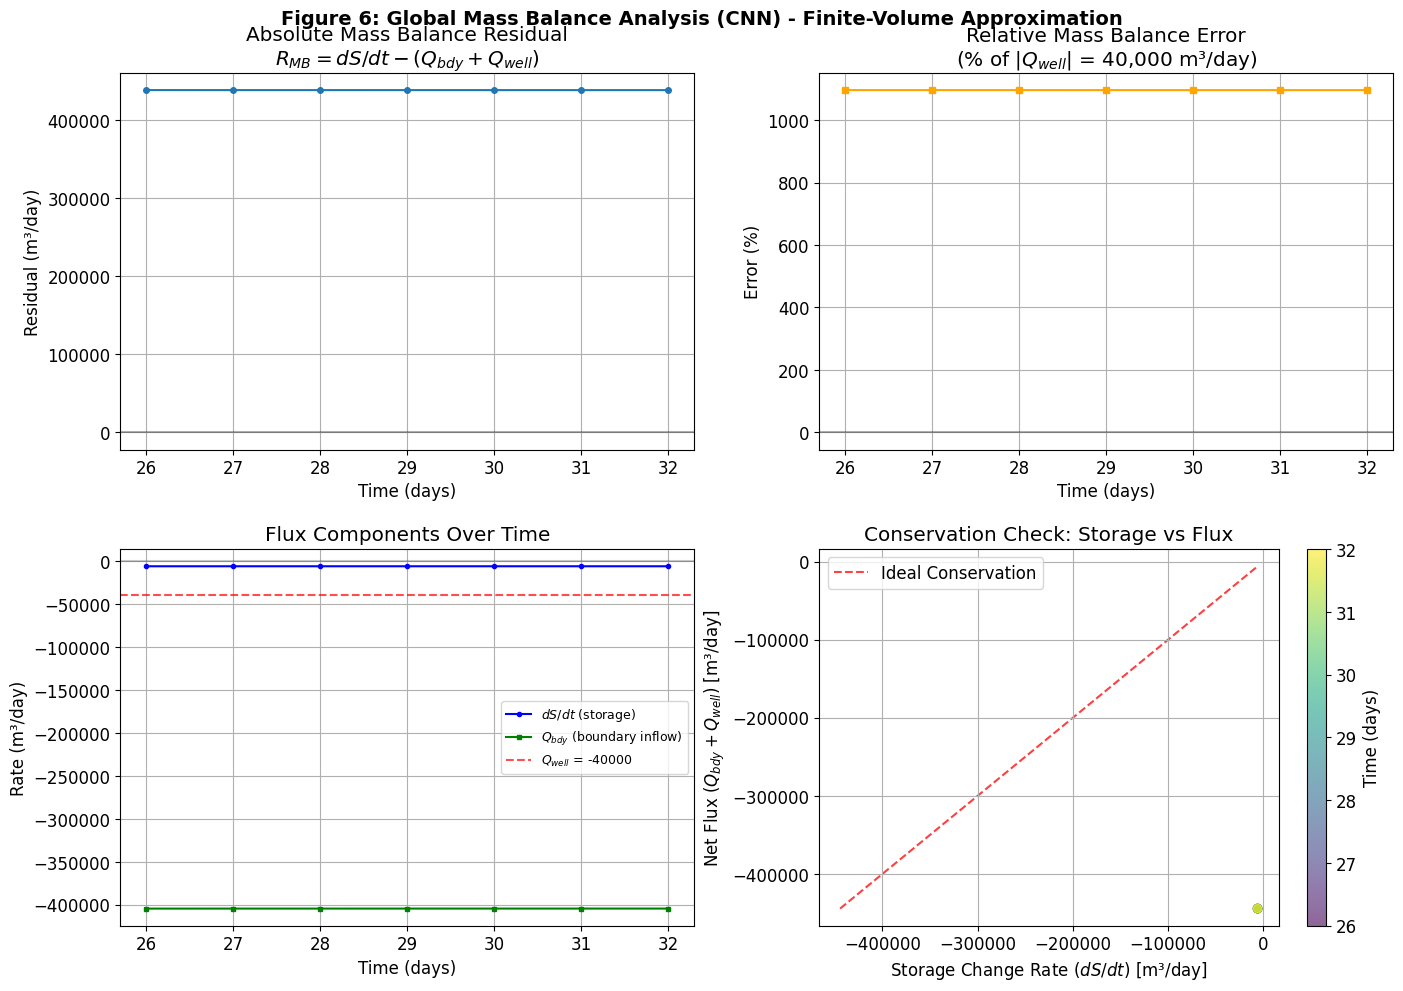

In [ ]:
# ============================================================================
# Mass Balance Error (CNN) - Finite-Volume
# ============================================================================

model.eval()

print("=" * 80)
print("FIGURE 6: MASS BALANCE ERROR (CNN) - HARMONIZED WITH PINN")
print("=" * 80)

# ---------------------------------------------------------
# Physical Parameters
# ---------------------------------------------------------
K     = 33.33        # m/day
Sy    = 0.10         # Specific yield
h0    = 90.0         # CHD boundary head (North/South)
Q_well_total = -40000.0  # m³/day (negative = pumping)

# Grid setup
nx, ny = 300, 300
x_val = np.linspace(-500, 500, nx)
y_val = np.linspace(-500, 500, ny)
dx_mb = x_val[1] - x_val[0]
dy_mb = y_val[1] - y_val[0]
cell_area = dx_mb * dy_mb
dt_cnn = 1.0

print(f"Grid: {nx}x{ny}, dx={dx_mb:.2f}m, dy={dy_mb:.2f}m")

# ---------------------------------------------------------
# Boundary Flux
# ---------------------------------------------------------
def boundary_flux_gradient(head_grid):
    """
    Compute net boundary inflow using Darcy's law with head-dependent
    transmissivity (T = K*h), matching PINN and Boussinesq formulation.

    South boundary = row 0  (y = y_min)
    North boundary = row -1 (y = y_max)
    East/West = no-flow

    Returns: (total_flux, Q_south, Q_north)
    Positive = into domain.
    """
    # South boundary: inward flux
    h_bdy_s = head_grid[0, :]     # boundary row
    h_int_s = head_grid[1, :]     # first interior row
    h_avg_s = 0.5 * (h_bdy_s + h_int_s)
    Q_south = np.sum(K * h_avg_s * (h_bdy_s - h_int_s) / dy_mb * dx_mb)

    # North boundary: inward flux
    h_bdy_n = head_grid[-1, :]    # boundary row
    h_int_n = head_grid[-2, :]    # first interior row
    h_avg_n = 0.5 * (h_bdy_n + h_int_n)
    Q_north = np.sum(K * h_avg_n * (h_bdy_n - h_int_n) / dy_mb * dx_mb)

    return Q_south + Q_north, Q_south, Q_north

# ---------------------------------------------------------
# Evaluate Mass Balance Over Test Set
# ---------------------------------------------------------
mb_errors = []
storage_terms = []
boundary_terms = []
forcing_terms = []
timesteps_plot = []

print(f"Evaluating Mass Balance over {len(test_ds)} test snapshots...\n")

with torch.no_grad():
    for i in range(len(test_ds)):
        xb, yb = test_ds[i]
        xb = xb.unsqueeze(0).to(device)

        # Predict h(t)
        pred = model(xb)

        # Get h(t-1) from input
        h_prev_tensor = xb[0, -1] if xb.ndim == 5 else xb[0, 0]

        # Denormalize
        h_t   = pred[0, 0].cpu().numpy() * train_ds.std + train_ds.mean
        h_tm1 = h_prev_tensor.cpu().numpy() * train_ds.std + train_ds.mean

        # A. Storage change rate: sum(Sy * dh/dt * cell_area)
        dh_dt = (h_t - h_tm1) / dt_cnn
        Rate_Storage = np.sum(Sy * dh_dt) * cell_area

        # B. Boundary flux (nonlinear, matching PINN)
        Rate_Boundary, _, _ = boundary_flux_gradient(h_t)

        # C. Well flux
        Rate_Wells = Q_well_total

        # D. Signed residual: dS/dt should equal (boundary inflow + well extraction)
        eps_MB = Rate_Storage - (Rate_Boundary + Rate_Wells)

        # Time label
        t_val = 26.0 + i

        mb_errors.append(eps_MB)
        storage_terms.append(Rate_Storage)
        boundary_terms.append(Rate_Boundary)
        forcing_terms.append(Rate_Boundary + Rate_Wells)
        timesteps_plot.append(t_val)

        print(f"  t={t_val:.1f} d | Storage={Rate_Storage:>10.1f} | "
              f"Bdy={Rate_Boundary:>10.1f} | R_MB={eps_MB:>10.1f} m³/day")

mb_errors = np.array(mb_errors)
storage_terms = np.array(storage_terms)
boundary_terms = np.array(boundary_terms)
forcing_terms = np.array(forcing_terms)
timesteps_plot = np.array(timesteps_plot)

# Relative error normalized by |Q_well| (stable reference, matching PINN)
rel_MB = 100.0 * mb_errors / np.abs(Q_well_total)

print(f"\n{'='*60}")
print(f"MASS BALANCE SUMMARY (CNN)")
print(f"{'='*60}")
print(f"Mean Abs Residual:   {np.mean(np.abs(mb_errors)):>10.1f} m³/day")
print(f"Max  Abs Residual:   {np.max(np.abs(mb_errors)):>10.1f} m³/day")
print(f"Mean Rel Error:      {np.mean(np.abs(rel_MB)):>10.2f} %  (of |Q_well|={np.abs(Q_well_total):.0f})")
print(f"{'='*60}")
print(f"Boundary inflow (first): {boundary_terms[0]:>10.1f} m³/day")
print(f"Boundary inflow (last):  {boundary_terms[-1]:>10.1f} m³/day")
print(f"Storage rate    (first): {storage_terms[0]:>10.1f} m³/day")
print(f"Storage rate    (last):  {storage_terms[-1]:>10.1f} m³/day")
print(f"{'='*60}")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(14, 10))

# Signed residual over time
ax1 = plt.subplot(2, 2, 1)
ax1.plot(timesteps_plot, mb_errors, 'o-', markersize=4, label='Residual')
ax1.axhline(0, ls='-', color='k', alpha=0.3)
ax1.set_title("Absolute Mass Balance Residual\n$R_{MB} = dS/dt - (Q_{bdy} + Q_{well})$")
ax1.set_ylabel("Residual (m³/day)")
ax1.set_xlabel("Time (days)")
ax1.grid(True)

#Relative error (% of |Q_well|)
ax2 = plt.subplot(2, 2, 2)
ax2.plot(timesteps_plot, rel_MB, 's-', markersize=4, color='orange')
ax2.axhline(0, ls='-', color='k', alpha=0.3)
ax2.set_title("Relative Mass Balance Error\n(% of $|Q_{well}|$ = 40,000 m³/day)")
ax2.set_ylabel("Error (%)")
ax2.set_xlabel("Time (days)")
ax2.grid(True)

# Flux components over time
ax3 = plt.subplot(2, 2, 3)
ax3.plot(timesteps_plot, storage_terms, 'b-o', markersize=3, label='$dS/dt$ (storage)')
ax3.plot(timesteps_plot, boundary_terms, 'g-s', markersize=3, label='$Q_{bdy}$ (boundary inflow)')
ax3.axhline(Q_well_total, ls='--', color='r', alpha=0.7, label=f'$Q_{{well}}$ = {Q_well_total:.0f}')
ax3.axhline(0, ls='-', color='k', alpha=0.2)
ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Rate (m³/day)")
ax3.set_title("Flux Components Over Time")
ax3.legend(fontsize=9)
ax3.grid(True)

# Storage vs Forcing scatter
ax4 = plt.subplot(2, 2, 4)
ax4.scatter(storage_terms, forcing_terms, alpha=0.6, c=timesteps_plot, cmap='viridis')
lims = [
    min(np.min(storage_terms), np.min(forcing_terms)),
    max(np.max(storage_terms), np.max(forcing_terms)),
]
ax4.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Ideal Conservation')
ax4.set_xlabel("Storage Change Rate ($dS/dt$) [m³/day]")
ax4.set_ylabel("Net Flux ($Q_{bdy} + Q_{well}$) [m³/day]")
ax4.set_title("Conservation Check: Storage vs Flux")
cb = plt.colorbar(ax4.collections[0], ax=ax4, label='Time (days)')
ax4.legend(loc='upper left')
ax4.grid(True)

plt.suptitle(
    "Figure 6: Global Mass Balance Analysis (CNN) - Finite-Volume Approximation",
    fontweight="bold", fontsize=14
)
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=1.5)
plt.show()

## 9. Boundary Condition Analysis – Dirichlet BC Consistency

Evaluates how well the CNN respects prescribed constant-head boundaries (CHD = 90 m on North and South walls).

### 9.1 Debug: Quick Boundary Value Check

> **Debug cell** — inspects raw CNN output at the domain boundaries for the first test sample. Used to verify BC behavior before full statistical analysis.

In [ ]:
# Check what the CNN predicts at the boundaries
xb, yb = test_ds[0]
xb = xb.unsqueeze(0).to(device)
pred = model(xb)
h_t = pred[0, 0].detach().cpu().numpy() * train_ds.std + train_ds.mean

print(f"North boundary (row -1): mean={h_t[-1,:].mean():.4f}, min={h_t[-1,:].min():.4f}, max={h_t[-1,:].max():.4f}")
print(f"South boundary (row 0):  mean={h_t[0,:].mean():.4f}, min={h_t[0,:].min():.4f}, max={h_t[0,:].max():.4f}")
print(f"First interior row (1):  mean={h_t[1,:].mean():.4f}")
print(f"Last interior row (-2):  mean={h_t[-2,:].mean():.4f}")
print(f"Domain center:           {h_t[150,150]:.4f}")
print(f"Expected CHD head:       {h0}")

North boundary (row -1): mean=89.5676, min=89.2195, max=89.5727
South boundary (row 0):  mean=89.5425, min=89.2023, max=89.5474
First interior row (1):  mean=89.7623
Last interior row (-2):  mean=89.7989
Domain center:           83.1396
Expected CHD head:       90.0


### 9.2  Dirichlet Boundary Condition Error Over Time

In [ ]:
# ============================================================================
# Dirichlet Boundary Condition Error
# ============================================================================

model.eval()

h0 = 90.0  # Prescribed CHD head (North & South only)

boundary_errors_all = []
mae_per_sample = []
max_per_sample = []
rmse_per_sample = []
timesteps = []

print("=" * 80)
print("FIGURE 8: DIRICHLET BOUNDARY CONDITION CONSISTENCY")
print("=" * 80)
print("Evaluating ONLY prescribed boundaries (North & South)")
print("Metric: ε_BC = |h_pred - h_BC|,  h_BC = 90 m")
print("East/West excluded (no-flow boundaries)")
print("-" * 80)

with torch.no_grad():
    for i, (xb, _) in enumerate(test_loader):
        xb = xb.to(device)
        pred = model(xb)

        h_pred = pred[0, 0].cpu().numpy() * train_ds.std + train_ds.mean

        # Dirichlet boundaries only
        pred_north = h_pred[0, :]
        pred_south = h_pred[-1, :]

        bc_north = np.full_like(pred_north, h0)
        bc_south = np.full_like(pred_south, h0)

        boundary_error = np.abs(
            np.concatenate([pred_north - bc_north,
                            pred_south - bc_south])
        )

        mae = boundary_error.mean()
        maxe = boundary_error.max()
        rmse = np.sqrt((boundary_error**2).mean())

        boundary_errors_all.extend(boundary_error)
        mae_per_sample.append(mae)
        max_per_sample.append(maxe)
        rmse_per_sample.append(rmse)
        timesteps.append(i + 1)

        if i == 0 or (i + 1) % 5 == 0:
            print(f"Timestep {i+1}: MAE={mae:.4f} m, Max={maxe:.4f} m")

boundary_errors_all = np.array(boundary_errors_all)
mae_per_sample = np.array(mae_per_sample)
max_per_sample = np.array(max_per_sample)
rmse_per_sample = np.array(rmse_per_sample)

print("\nBOUNDARY ERROR SUMMARY:")
print(f"Mean MAE:  {mae_per_sample.mean():.4f} m")
print(f"Mean Max:  {max_per_sample.mean():.4f} m")
print(f"Mean RMSE: {rmse_per_sample.mean():.4f} m")
print(f"95th pct:  {np.percentile(boundary_errors_all,95):.4f} m")
print("=" * 80)


FIGURE 8: DIRICHLET BOUNDARY CONDITION CONSISTENCY
Evaluating ONLY prescribed boundaries (North & South)
Metric: ε_BC = |h_pred - h_BC|,  h_BC = 90 m
East/West excluded (no-flow boundaries)
--------------------------------------------------------------------------------
Timestep 1: MAE=0.4450 m, Max=0.7977 m
Timestep 5: MAE=0.4450 m, Max=0.7977 m

BOUNDARY ERROR SUMMARY:
Mean MAE:  0.4450 m
Mean Max:  0.7977 m
Mean RMSE: 0.4460 m
95th pct:  0.4561 m
